# CIFAR-10 Advanced Functional Architectures

This notebook applies graph-based network design to CIFAR-10. It includes a functional CNN baseline, parallel branches, skip connections, combined branch-and-skip designs, Inception-style modules, residual networks, and residual networks with parallel branches.


## Setup and CIFAR-10 Data


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import *
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
(x_train, y_train_raw), (x_test, y_test_raw) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# One-hot encode the labels
y_train = to_categorical(y_train_raw.flatten(), 10)
y_test  = to_categorical(y_test_raw.flatten(), 10)

In [ ]:
def plot_results(all_history):
  loss, val_loss, accuracy, val_accuracy = [], [], [], []
  for history in all_history:
    loss += history.history['loss']
    val_loss += history.history['val_loss']
    accuracy += history.history['accuracy']
    val_accuracy += history.history['val_accuracy']

  fig, ax = plt.subplots()
  ax.plot(accuracy,label = 'train')
  ax.plot(val_accuracy,label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(loss,label = 'train')
  ax.plot(val_loss,label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')


## Functional CNN Baseline with Batch Normalization and Dropout


In [ ]:
def cnn_model_api(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Block 1
    net = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    net = BatchNormalization()(net)
    net = Conv2D(32, (3, 3), activation='relu', padding='same')(net)
    net = BatchNormalization()(net)
    net = MaxPooling2D(pool_size=(2, 2))(net)
    net = Dropout(0.25)(net)

    # Block 2
    net = Conv2D(64, (3, 3), activation='relu', padding='same')(net)
    net = BatchNormalization()(net)
    net = Conv2D(64, (3, 3), activation='relu', padding='same')(net)
    net = BatchNormalization()(net)
    net = MaxPooling2D(pool_size=(2, 2))(net)
    net = Dropout(0.25)(net)

    # Block 3
    net = Conv2D(128, (3, 3), activation='relu', padding='same')(net)
    net = BatchNormalization()(net)
    net = Conv2D(128, (3, 3), activation='relu', padding='same')(net)
    net = BatchNormalization()(net)
    net = MaxPooling2D(pool_size=(2, 2))(net)
    net = Dropout(0.4)(net)

    # Fully connected layers
    net = Flatten()(net)
    net = Dense(256, activation='relu')(net)
    net = BatchNormalization()(net)
    net = Dropout(0.5)(net)

    outputs = Dense(num_classes, activation='softmax')(net)

    # Define model
    model = Model(inputs=inputs, outputs=outputs, name='cifar10_functional_model')
    return model


In [ ]:
cnn = cnn_model_api()
cnn.summary()


Model: "cifar10_functional_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_205 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_117         │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_206 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_118         │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_207 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_119         │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_208 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_120         │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_209 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_121         │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_210 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_122         │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_123         │ (None, 256)            │         1,02

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

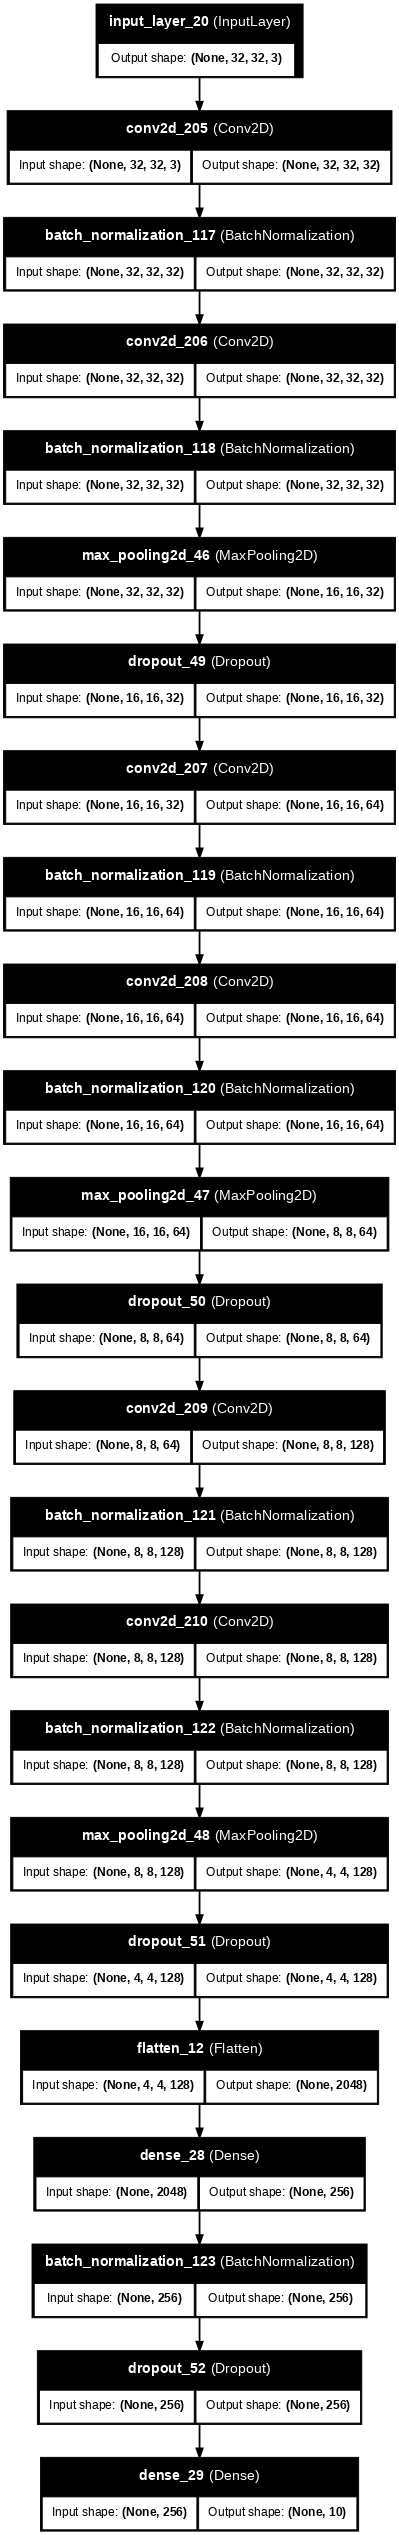

In [ ]:
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True, dpi=64)


In [ ]:
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(np.mean(history.history['val_accuracy'][-1])))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.4259 - loss: 1.7694 - val_accuracy: 0.1087 - val_loss: 3.8974
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6240 - loss: 1.0706 - val_accuracy: 0.3019 - val_loss: 2.3366
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7017 - loss: 0.8489 - val_accuracy: 0.6516 - val_loss: 0.9905
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7426 - loss: 0.7329 - val_accuracy: 0.6999 - val_loss: 0.8909
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7704 - loss: 0.6583 - val_accuracy: 0.7551 - val_loss: 0.7264
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7913 - loss: 0.5978 - val_accuracy: 0.7433 - val_loss: 0.7761
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8088 - loss: 0.5572 - val_accuracy: 0.7286 - val_loss: 0.8127
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8196 - loss: 0.5162 - val_accuracy: 

## Parallel-Branch CNN


In [ ]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(branch3)
  concatanated = Concatenate()([branch1,branch2,branch3])
  net = MaxPooling2D(pool_size=(2, 2))(concatanated)
  net = Dropout(0.2)(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


In [ ]:
cnn = cnn_model_api(input_shape=x_train.shape[1:])
# plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
!pip install graphviz

In [ ]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))

Epoch 1/40
500/500 - 12s - 23ms/step - accuracy: 0.3863 - loss: 1.6571 - val_accuracy: 0.5309 - val_loss: 1.2828
Epoch 2/40
500/500 - 3s - 6ms/step - accuracy: 0.5746 - loss: 1.1836 - val_accuracy: 0.6537 - val_loss: 0.9780
Epoch 3/40
500/500 - 3s - 6ms/step - accuracy: 0.6606 - loss: 0.9616 - val_accuracy: 0.7028 - val_loss: 0.8468
Epoch 4/40
500/500 - 3s - 6ms/step - accuracy: 0.7065 - loss: 0.8374 - val_accuracy: 0.7319 - val_loss: 0.7651
Epoch 5/40
500/500 - 3s - 6ms/step - accuracy: 0.7348 - loss: 0.7522 - val_accuracy: 0.7521 - val_loss: 0.7309
Epoch 6/40
500/500 - 3s - 6ms/step - accuracy: 0.7641 - loss: 0.6801 - val_accuracy: 0.7584 - val_loss: 0.6970
Epoch 7/40
500/500 - 3s - 6ms/step - accuracy: 0.7837 - loss: 0.6217 - val_accuracy: 0.7747 - val_loss: 0.6713
Epoch 8/40
500/500 - 3s - 6ms/step - accuracy: 0.7999 - loss: 0.5749 - val_accuracy: 0.7947 - val_loss: 0.6162
Epoch 9/40
500/500 - 3s - 6ms/step - accuracy: 0.8139 - loss: 0.5296 - val_accuracy: 0.7912 - val_loss: 0.6270

## Skip-Connection CNN


In [ ]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


In [ ]:
cnn = cnn_model_api(input_shape=x_train.shape[1:])
# plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/40
500/500 - 9s - 18ms/step - accuracy: 0.3967 - loss: 1.6307 - val_accuracy: 0.5644 - val_loss: 1.1905
Epoch 2/40
500/500 - 2s - 4ms/step - accuracy: 0.5847 - loss: 1.1601 - val_accuracy: 0.6370 - val_loss: 1.0412
Epoch 3/40
500/500 - 2s - 4ms/step - accuracy: 0.6609 - loss: 0.9613 - val_accuracy: 0.7097 - val_loss: 0.8343
Epoch 4/40
500/500 - 2s - 4ms/step - accuracy: 0.7065 - loss: 0.8405 - val_accuracy: 0.7318 - val_loss: 0.7574
Epoch 5/40
500/500 - 2s - 4ms/step - accuracy: 0.7352 - loss: 0.7601 - val_accuracy: 0.7564 - val_loss: 0.7015
Epoch 6/40
500/500 - 2s - 4ms/step - accuracy: 0.7557 - loss: 0.6991 - val_accuracy: 0.7600 - val_loss: 0.6848
Epoch 7/40
500/500 - 2s - 4ms/step - accuracy: 0.7746 - loss: 0.6453 - val_accuracy: 0.7770 - val_loss: 0.6413
Epoch 8/40
500/500 - 2s - 4ms/step - accuracy: 0.7867 - loss: 0.6059 - val_accuracy: 0.7933 - val_loss: 0.6270
Epoch 9/40
500/500 - 2s - 4ms/step - accuracy: 0.8006 - loss: 0.5693 - val_accuracy: 0.7891 - val_loss: 0.6188


## Combined Parallel Branches and Skip Connections


In [ ]:
def cnn_model_api(input_shape=(28,28,1), conv_units=(32,64,128,256)):
  inputs = Input(shape=input_shape)
  #parallel branches
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(branch3)
  concatanated = Concatenate()([branch1,branch2,branch3])
  net = MaxPooling2D(pool_size=(2, 2))(concatanated)
  net = Dropout(0.2)(net)
  #skip connection
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  skip = MaxPooling2D(pool_size=(2, 2))(net)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(skip)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  added = Add()([net,skip])
  net = MaxPooling2D(pool_size=(2, 2))(added)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


In [ ]:
cnn = cnn_model_api(input_shape=x_train.shape[1:])
# plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  40,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/40
500/500 - 14s - 28ms/step - accuracy: 0.3417 - loss: 1.7547 - val_accuracy: 0.4758 - val_loss: 1.4026
Epoch 2/40
500/500 - 3s - 6ms/step - accuracy: 0.5250 - loss: 1.3002 - val_accuracy: 0.5707 - val_loss: 1.1763
Epoch 3/40
500/500 - 3s - 6ms/step - accuracy: 0.6072 - loss: 1.0976 - val_accuracy: 0.6454 - val_loss: 0.9750
Epoch 4/40
500/500 - 3s - 6ms/step - accuracy: 0.6478 - loss: 0.9957 - val_accuracy: 0.6812 - val_loss: 0.8913
Epoch 5/40
500/500 - 3s - 6ms/step - accuracy: 0.6771 - loss: 0.9186 - val_accuracy: 0.6950 - val_loss: 0.8759
Epoch 6/40
500/500 - 3s - 6ms/step - accuracy: 0.6980 - loss: 0.8543 - val_accuracy: 0.7085 - val_loss: 0.8413
Epoch 7/40
500/500 - 3s - 6ms/step - accuracy: 0.7170 - loss: 0.8045 - val_accuracy: 0.7269 - val_loss: 0.7823
Epoch 8/40
500/500 - 3s - 6ms/step - accuracy: 0.7328 - loss: 0.7631 - val_accuracy: 0.7419 - val_loss: 0.7509
Epoch 9/40
500/500 - 3s - 6ms/step - accuracy: 0.7477 - loss: 0.7126 - val_accuracy: 0.7381 - val_loss: 0.7604

## Inception-Style CIFAR-10 Network


In [ ]:
import tensorflow.keras.layers as layers

def inception_module(x, filters_1x1, filters_3x3, filters_5x5, filters_pool_proj):
    # 1x1 conv branch
    conv1x1 = layers.Conv2D(filters_1x1, (1, 1), padding='same', activation='relu')(x)

    # 3x3 conv branch
    conv3x3 = layers.Conv2D(filters_3x3, (3, 3), padding='same', activation='relu')(x)

    # 5x5 conv branch
    conv5x5 = layers.Conv2D(filters_5x5, (5, 5), padding='same', activation='relu')(x)

    # 3x3 max pooling branch
    pool_proj = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = layers.Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu')(pool_proj)

    # Concatenate filters
    output = layers.concatenate([conv1x1, conv3x3, conv5x5, pool_proj], axis=-1)
    return output

In [ ]:
import tensorflow.keras.layers as layers
from tensorflow.keras import Model, Input

def inception_cifar10(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Initial conv layer
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    # Inception Block 1
    x = inception_module(x, 32, 32, 32, 32)
    x = layers.MaxPooling2D((2, 2))(x)

    # Inception Block 2
    x = inception_module(x, 64, 64, 64, 64)
    x = layers.MaxPooling2D((2, 2))(x)

    # Inception Block 3
    x = inception_module(x, 128, 128, 128, 128)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name="Inception_CIFAR10")
    return model

In [ ]:
model = inception_cifar10()
model.summary()

Model: "Inception_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 32, 32,    │      1,792 │ input_layer_16[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_40    │ (None, 16, 16,    │          0 │ conv2d_103[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_41    │ (None, 16, 16,    │          0 │ max_pooling2d_40… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 16, 16,    │      2,080 │ max_pooling2d_40… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 16, 16,    │     18,464 │ max_pooling2d_40… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 16, 16,    │     51,232 │ max_pooling2d_40… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 16, 16,    │      2,080 │ max_pooling2d_41… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 16, 16,    │          0 │ conv2d_104[0][0], │
│ (Concatenate)       │ 128)              │            │ conv2d_105[0][0], │
│                     │                   │            │ conv2d_106[0][0], │
│                     │                   │            │ conv2d_107[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_42    │ (None, 8, 8, 128) │          0 │ concatenate_7[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_43    │ (None, 8, 8, 128) │          0 │ max_pooling2d_42… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 8, 8, 64)  │      8,256 │ max_pooling2d_42… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 8, 8, 64)  │     73,792 │ max_pooling2d_42… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 8, 8, 64)  │    204,864 │ max_pooling2d_42… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 8, 8, 64)  │      8,256 │ max_pooling2d_43… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 8, 8, 256) │          0 │ conv2d_108[0][0], │
│ (Concatenate)       │                   │            │ conv2d_109[0][0], │
│                     │                   │            │ conv2d_110[0][0], │
│                     │                   │            │ conv2d_111[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_44    │ (None, 4, 4, 256) │          0 │ concatenate_8[0]

 Total params: 1,556,106 (5.94 MB)

 Trainable params: 1,556,106 (5.94 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 148ms/step - accuracy: 0.7708 - loss: 0.6542 - val_accuracy: 0.7143 - val_loss: 0.8649
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7969 - loss: 0.5804 - val_accuracy: 0.6808 - val_loss: 1.0112
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8155 - loss: 0.5250 - val_accuracy: 0.7150 - val_loss: 0.9200
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.8267 - loss: 0.4911 - val_accuracy: 0.7254 - val_loss: 0.8386
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8437 - loss: 0.4455 - val_accuracy: 0.7350 - val_loss: 0.8144
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8571 - loss: 0.4103 - val_accuracy: 0.7259 - val_loss: 0.8922
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8678 - loss: 0.3741 - val_accuracy: 0.6968 - val_loss: 0.9759
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8776 - loss: 0.3451 -

## Residual Network


In [ ]:
def residual_block(x, filters, downsample=False):
    """
    Residual block with optional downsampling.
    If downsample=True, reduces spatial dimension by stride=2.
    """
    shortcut = x

    stride = 2 if downsample else 1

    # First conv layer
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same',
                      use_bias=False, activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second conv layer
    x = layers.Conv2D(filters, (3, 3), padding='same',
                      use_bias=False, activation=None)(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut if dimensions differ (for downsampling or channel mismatch)
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride,
                                 padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x


In [ ]:
def resnet_cifar10(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Residual blocks
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)

    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)

    # Global average pooling and classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='ResNet_CIFAR10')
    return model


In [ ]:
model = resnet_cifar10()
model.summary()


Model: "ResNet_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_252 (Conv2D) │ (None, 32, 32,    │        864 │ input_layer_25[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_252[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_52 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_253 (Conv2D) │ (None, 32, 32,    │      9,216 │ re_lu_52[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_253[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_53 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_254 (Conv2D) │ (None, 32, 32,    │      9,216 │ re_lu_53[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_254[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_41 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu_52[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_54 (ReLU)     │ (None, 32, 32,    │          0 │ add_41[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_255 (Conv2D) │ (None, 32, 32,    │      9,216 │ re_lu_54[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_255[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_55 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_256 (Conv2D) │ (None, 32, 32,    │      9,216 │ re_lu_55[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_256[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_42 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 698,858 (2.67 MB)

 Trainable params: 696,618 (2.66 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [ ]:
#plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.4280 - loss: 1.6016 - val_accuracy: 0.1487 - val_loss: 3.6111
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6192 - loss: 1.0756 - val_accuracy: 0.4831 - val_loss: 1.5197
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6995 - loss: 0.8594 - val_accuracy: 0.6652 - val_loss: 0.9324
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7505 - loss: 0.7252 - val_accuracy: 0.6479 - val_loss: 1.0541
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7868 - loss: 0.6232 - val_accuracy: 0.5860 - val_loss: 1.3819
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8153 - loss: 0.5422 - val_accuracy: 0.6767 - val_loss: 0.9672
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8419 - loss: 0.4661 - val_accuracy: 0.6871 - val_loss: 1.0068
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8613 - loss: 0.4093 - val_acc

## Residual Network with Parallel Branches


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, Add, GlobalAveragePooling2D, Dense, Concatenate

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

def convolutional_block(X, filters, kernel_size=(3, 3), strides=(1, 1), padding='same'):
    F1, F2 = filters

    X_shortcut = X

    X = Conv2D(F1, kernel_size, strides=strides, padding=padding)(X)
    X = BatchNormalization()(X)
    X = ReLU()(X)

    X = Conv2D(F2, kernel_size, strides=(1, 1), padding=padding)(X)
    X = BatchNormalization()(X)

    # Shortcut path
    X_shortcut = Conv2D(F2, kernel_size=(1, 1), strides=strides, padding=padding)(X_shortcut)
    X_shortcut = BatchNormalization()(X_shortcut)

    X = Add()([X, X_shortcut])

    return X

def parallel_branch(X, filters, kernel_size=(3, 3), strides=(1, 1), padding='same'):
    X1 = convolutional_block(X, filters, kernel_size, strides, padding)
    X2 = convolutional_block(X1, filters, kernel_size, strides, padding)
    X3 = convolutional_block(X2, filters, kernel_size, strides, padding)

    return [X1, X2, X3]

def ResNetParallelBranches(input_shape=(32, 32, 3), classes=10):
    X_input = Input(input_shape)

    X = Conv2D(64, (7, 7), strides=(2, 2), padding='same')(X_input)
    X = BatchNormalization()(X)
    X = ReLU()(X)

    # Parallel branches
    branches = parallel_branch(X, filters=[64, 64])
    X = Concatenate()(branches)

    X = parallel_branch(X, filters=[64, 64])
    X = Concatenate()(X)

    X = parallel_branch(X, filters=[128, 128])
    X = Concatenate()(X)

    X = parallel_branch(X, filters=[256, 256])
    X = Concatenate()(X)

    X = GlobalAveragePooling2D()(X)

    X = Dense(classes, activation='softmax')(X)

    model = tf.keras.models.Model(inputs=X_input, outputs=X)

    return model


model = ResNetParallelBranches(input_shape=(32, 32, 3), classes=10)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_267 (Conv2D) │ (None, 16, 16,    │      9,472 │ input_layer_26[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_267[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_65 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_268 (Conv2D) │ (None, 16, 16,    │     36,928 │ re_lu_65[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_268[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_66 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_269 (Conv2D) │ (None, 16, 16,    │     36,928 │ re_lu_66[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_270 (Conv2D) │ (None, 16, 16,    │      4,160 │ re_lu_65[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_269[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_270[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_47 (Add)        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_271 (Conv2D) │ (None, 16, 16,    │     36,928 │ add_47[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_271[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_67 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_272 (Conv2D) │ (None, 16, 16,    │     36,928 │ re_lu_67[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_273 (Conv2D) │ (None, 16, 16,    │      4,160 │ add_47[0][0]    

 Total params: 5,668,362 (21.62 MB)

 Trainable params: 5,659,018 (21.59 MB)

 Non-trainable params: 9,344 (36.50 KB)

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:


(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


model = ResNetParallelBranches(input_shape=(32, 32, 3), classes=10)


model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])



early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               mode='min',
                               verbose=1,
                               restore_best_weights=True)

history = model.fit(x_train, y_train,
                    epochs=30,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=[early_stopping])


test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.4123 - loss: 1.6078 - val_accuracy: 0.2966 - val_loss: 2.3662
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5511 - loss: 1.2454 - val_accuracy: 0.3324 - val_loss: 2.7062
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6158 - loss: 1.0752 - val_accuracy: 0.3373 - val_loss: 3.6611
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6589 - loss: 0.9579 - val_accuracy: 0.5961 - val_loss: 1.1727
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7029 - loss: 0.8412 - val_accuracy: 0.4863 - val_loss: 1.8002
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7337 - loss: 0.7659 - val_accuracy: 0.5169 - val_loss: 1.5342
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7566 - loss: 0.6974 - val_accuracy: 0.7115 - val_loss: 0.8167
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7768 - loss: 0.6397 - 

## Alternate Functional CIFAR-10 Baseline


In [ ]:
def cnn_model_api(input_shape=(28,28,1)):
  inputs = Input(shape=input_shape)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  net = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = BatchNormalization()(net)
  net = Dropout(0.2)(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = BatchNormalization()(net)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = BatchNormalization()(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model


In [ ]:
cnn = cnn_model_api(input_shape=x_train.shape[1:])
cnn.summary()


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_341 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_342 (Conv2D)             │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_228         │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_343 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_344 (Conv2D)             │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_229         │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_345 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_346 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_230         │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,466 (2.10 MB)

 Trainable params: 551,018 (2.10 MB)

 Non-trainable params: 448 (1.75 KB)

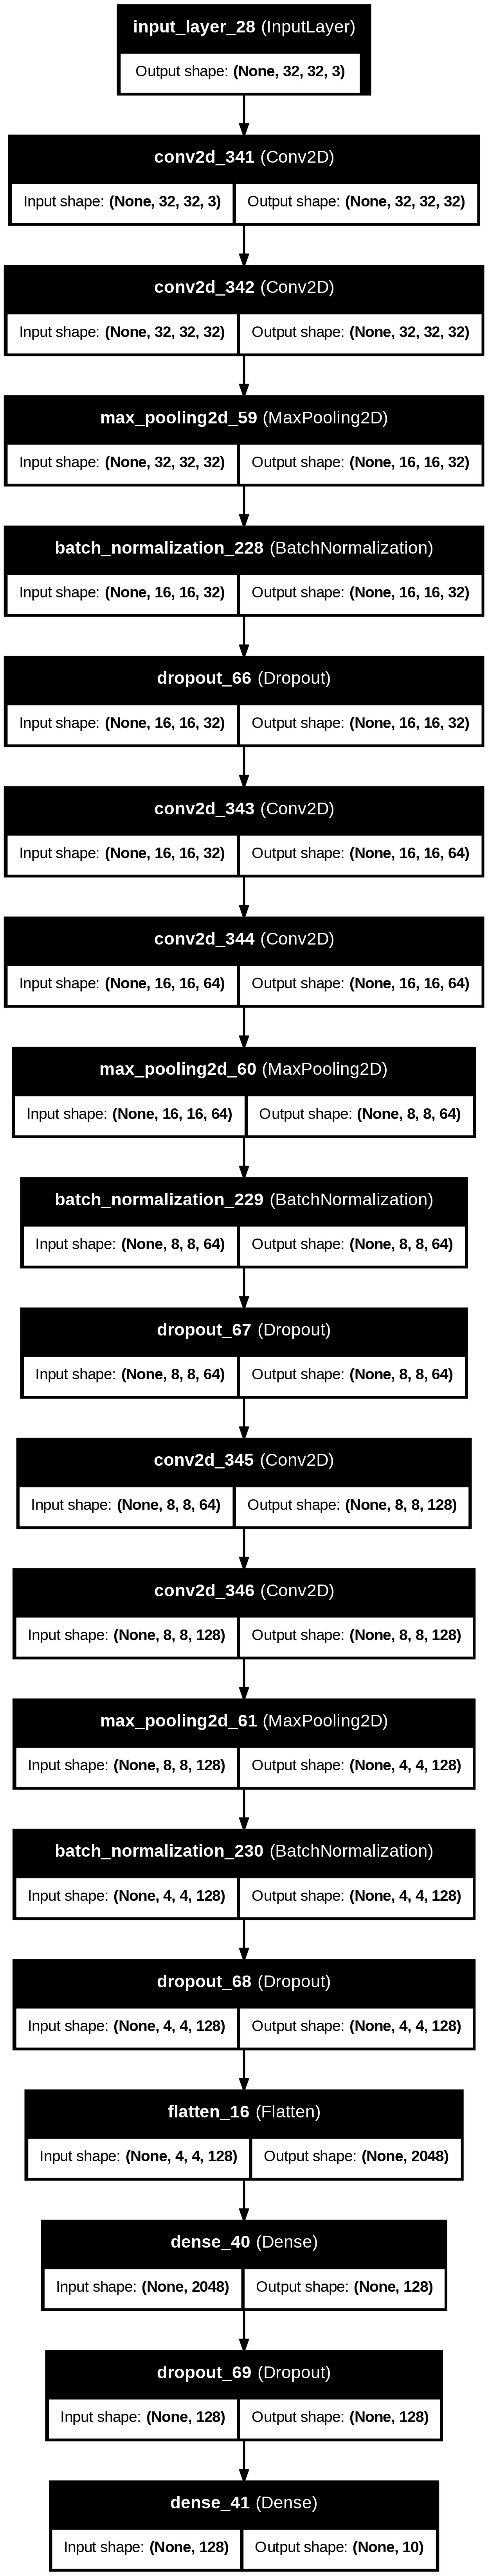

In [ ]:
plot_model(cnn, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(
    x_train, y_train,
    epochs =  10,
    batch_size=100,
    verbose = 2,
    validation_data=(x_test, y_test),
)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))
print('Mean accuracy in last 5 epochs: {:.4f}'.format(np.mean(history.history['val_accuracy'][-5:])))


Epoch 1/10
500/500 - 12s - 23ms/step - accuracy: 0.4790 - loss: 1.4548 - val_accuracy: 0.3009 - val_loss: 2.9572
Epoch 2/10
500/500 - 2s - 5ms/step - accuracy: 0.6433 - loss: 1.0092 - val_accuracy: 0.6747 - val_loss: 0.9340
Epoch 3/10
500/500 - 2s - 5ms/step - accuracy: 0.7094 - loss: 0.8258 - val_accuracy: 0.7164 - val_loss: 0.8119
Epoch 4/10
500/500 - 2s - 5ms/step - accuracy: 0.7476 - loss: 0.7162 - val_accuracy: 0.7204 - val_loss: 0.8214
Epoch 5/10
500/500 - 2s - 5ms/step - accuracy: 0.7790 - loss: 0.6354 - val_accuracy: 0.7484 - val_loss: 0.7269
Epoch 6/10
500/500 - 2s - 5ms/step - accuracy: 0.8008 - loss: 0.5754 - val_accuracy: 0.7680 - val_loss: 0.6905
Epoch 7/10
500/500 - 2s - 5ms/step - accuracy: 0.8163 - loss: 0.5240 - val_accuracy: 0.7849 - val_loss: 0.6595
Epoch 8/10
500/500 - 2s - 5ms/step - accuracy: 0.8292 - loss: 0.4848 - val_accuracy: 0.7342 - val_loss: 0.8615
Epoch 9/10
500/500 - 2s - 5ms/step - accuracy: 0.8433 - loss: 0.4479 - val_accuracy: 0.7709 - val_loss: 0.6954

## Architecture Progression

The experiments progress from a conventional Functional API CNN to increasingly flexible computation graphs. Parallel feature extraction, residual shortcuts, and Inception-style branch fusion illustrate core ideas used in many modern vision architectures.
